# Regression


In [55]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

### Divide the data into train and test

In [64]:
# CSV
df = pd.read_csv("Mobile-Price-Prediction-cleaned_data.csv" )

X = df.iloc[:, :-1]  
Y = df.iloc[:, -1] 

print(X.head())
print("-------------------------------------")
print(Y.head())



xTrain, xTest, yTrain, yTest = train_test_split(X, Y, test_size=0.2, random_state=42)

# not scaled data
xTrainNoStd=xTrain
xTestNoStd=xTest

# scaled data
scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xTest  = scaler.transform(xTest)

print("Train :", xTrain.shape, yTrain.shape)
print("Test :", xTest.shape, yTest.shape)



   Ratings  RAM    ROM  Mobile_Size  Primary_Cam  Selfi_Cam  Battery_Power
0      4.3  4.0  128.0         6.00           48       13.0           4000
1      3.4  6.0   64.0         4.50           48       12.0           4000
2      4.3  4.0    4.0         4.50           64       16.0           4000
3      4.4  6.0   64.0         6.40           48       15.0           3800
4      4.5  6.0  128.0         6.18           35       15.0           3800
-------------------------------------
0    24999
1    15999
2    15000
3    18999
4    18999
Name: Price, dtype: int64
Train : (645, 7) (645,)
Test : (162, 7) (162,)


### Using closed form solution

In [65]:
# L(w)=(XW-Y)^T (XW-Y)
# => Wopt=(X^T X)^(-1) X^T Y

def biadAdd(X):
    ''' Adds a ones column to X (for the bias)'''
    return np.hstack([np.ones((X.shape[0], 1)), X])

xTrainClosed = biadAdd(xTrain)
xTestClosed  = biadAdd(xTest)

# w-optimal
XtX = xTrainClosed.T @ xTrainClosed
Xty = xTrainClosed.T @ yTrain
wOpt = np.linalg.pinv(XtX) @ Xty  

# Predictions
yPredClosed = xTestClosed @ wOpt

# Metrics
rmseClosed = root_mean_squared_error(yTest, yPredClosed)
r2Closed  = r2_score(yTest, yPredClosed)

print(f"Closed-form linear regression (no regularisation) | Test RMSE: {rmseClosed:.4f} | R^2: {r2Closed:.4f}")


Closed-form linear regression (no regularisation) | Test RMSE: 15471.1880 | R^2: 0.4332


### Using gradient descent

In [66]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def GDLinearReg(X, y, lr=1e-3, epochs=5000, verbose=False):
    ''' Xb: (n, d+1) (with bias column)     
        y:  (n, 1) '''
    n, dPlus1 = X.shape
    w = np.zeros((dPlus1, 1))
    for e in range(epochs):
        yHat = X @ w
        grad = (2/n) * (X.T @ (yHat- y))  # dL(w)/dw
        w -= lr * grad
        if verbose and (e % (epochs//5) == 0 or e == epochs-1):
            print(f"epoch {e:5d} | mse={mse(y, yHat):.6f}")
    return w

 
xTrainGD = biadAdd(xTrain)
xTestGD  = biadAdd(xTest)

wOptGD = GDLinearReg(xTrainGD, yTrain.values.reshape(-1,1), lr=.005, epochs=500)
yPredGD = (xTestGD @ wOptGD).ravel()

rmseGD = root_mean_squared_error(yTest, yPredGD)
r2GD  = r2_score(yTest, yPredGD)


print(f"Gradient Descent linear regression (no regularisation)| Test RMSE: {rmseGD:.4f} | R^2: {r2GD:.4f}")


Gradient Descent linear regression (no regularisation)| Test RMSE: 15412.2799 | R^2: 0.4375


### Plot the predicted verses actual on test data for both the methods

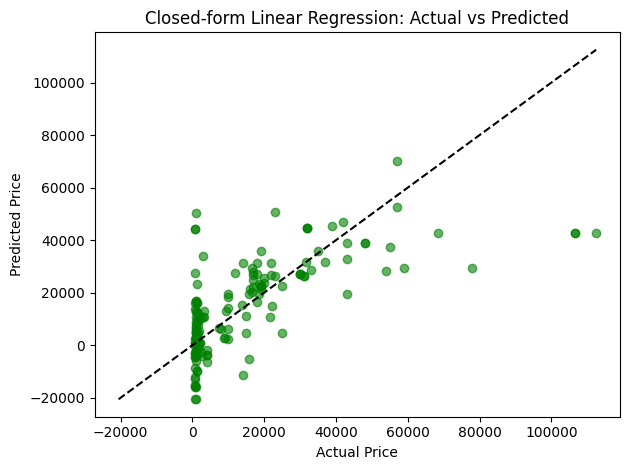

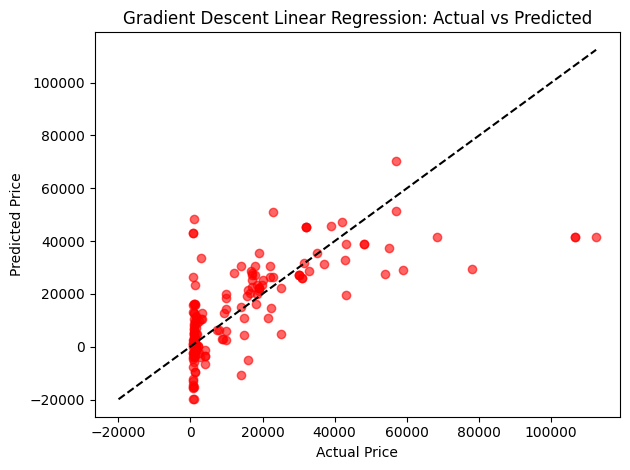

In [67]:
def plotPredActual(yTrue, yPred, title, color):
    plt.scatter(yTrue, yPred, alpha=0.6, color=color)
    
    minV = min(yTrue.min(), yPred.min()) #min max values
    maxV = max(yTrue.max(), yPred.max())
    
    # y = x reference line
    plt.plot([minV, maxV], [minV, maxV], linestyle='--', color="black")
    
    plt.xlabel("Actual Price") #labels
    plt.ylabel("Predicted Price")
    plt.title(title)
    
    plt.tight_layout()
    plt.show()


# Plot for Closed Form
plotPredActual(yTest, yPredClosed, "Closed-form Linear Regression: Actual vs Predicted", "green")

# Plot for Gradient Descent
plotPredActual(yTest, yPredGD, "Gradient Descent Linear Regression: Actual vs Predicted", "red")


### Ridge Regression (Closed form and Gradient Descent with Plots)

Ridge Regression (λ=200) Closed-form | Test RMSE: 15061.9584 | R^2: 0.4628
Ridge Regression (λ=200) GD          | Test RMSE: 15061.9420 | R^2: 0.4628


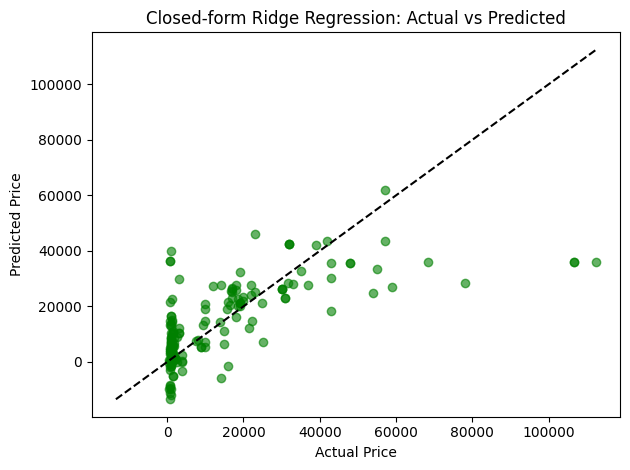

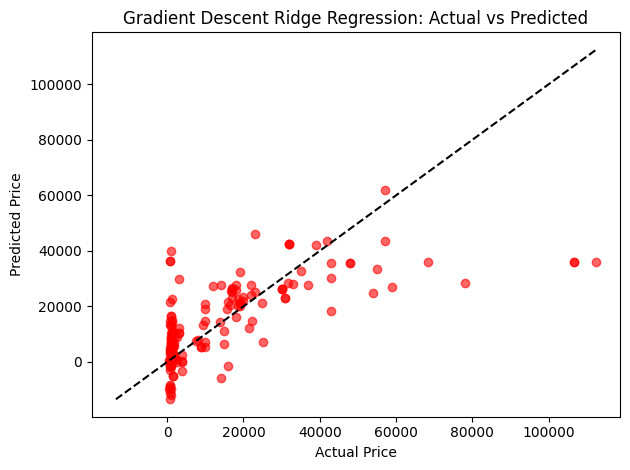

In [70]:
def ridgeClosed(X, Y, lam=1.0):
    Y = Y.values.reshape(-1,1) 
    dplus1 = X.shape[1]
    I = np.eye(dplus1)
    I[0, 0] = 0.0  # don't regularize bias
    XtX = X.T @ X
    Xty = X.T @ Y
    wOpt = np.linalg.pinv(XtX + lam * I) @ Xty
    return wOpt

def ridgeGD(X, Y, lam=1.0, lr=1e-3, epochs=5000, verbose=False):
    Y = Y.values.reshape(-1,1) 
    n, dPlus1 = X.shape
    w = np.zeros((dPlus1, 1))
    I = np.eye(dPlus1)
    I[0, 0] = 0.0  # don't regularize bias
    for e in range(epochs):
        yHat = X @ w
        grad = (2/n) * (X.T @ (yHat - Y)) + (2*lam/n) * (I @ w)
        w -= lr * grad
        if verbose and (e % (epochs//5) == 0 or e == epochs-1):
            print(f"epoch {e:5d} | mse={mse(Y, yHat):.6f}")
    return w

# Train both
wOptClosedRidge = ridgeClosed(xTrainClosed, yTrain, lam=200)
wOptGDRidge     = ridgeGD(xTrainGD, yTrain, lam=200, lr=1e-3, epochs=5000)

# Predictions
yPredClosedRidge = xTestClosed @ wOptClosedRidge
yPredGDRidge     = xTestGD @ wOptGDRidge

# Metrics
print(f"Ridge Regression (λ=200) Closed-form | Test RMSE: {root_mean_squared_error(yTest, yPredClosedRidge):.4f} | R^2: {r2_score(yTest, yPredClosedRidge):.4f}")
print(f"Ridge Regression (λ=200) GD          | Test RMSE: {root_mean_squared_error(yTest, yPredGDRidge):.4f} | R^2: {r2_score(yTest, yPredGDRidge):.4f}")

# Plot for Closed Form
plotPredActual(yTest, yPredClosedRidge, "Closed-form Ridge Regression: Actual vs Predicted", "green")

# Plot for Gradient Descent
plotPredActual(yTest, yPredGDRidge, "Gradient Descent Ridge Regression: Actual vs Predicted", "red")


### Compare Ridge With vs Without Standardization

Ridge (λ=200) WITHOUT standardisation | Test RMSE: 16231.8718 | R^2: 0.3761
Ridge (λ=200) WITH standardisation    | Test RMSE: 15061.9584   | R^2: 0.4628


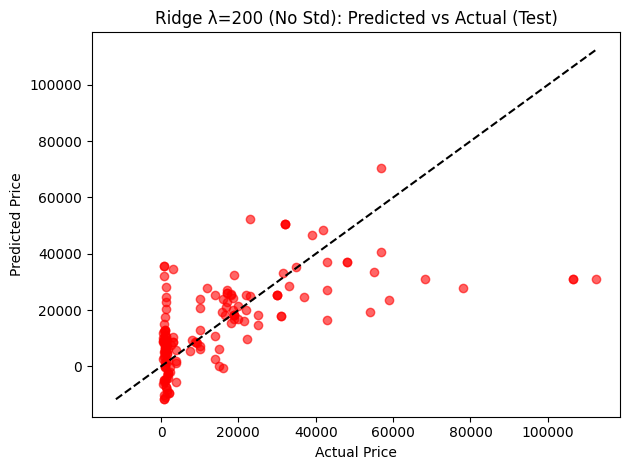

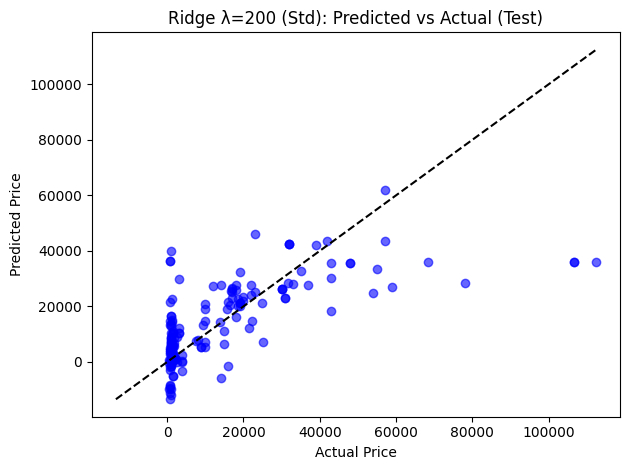

In [71]:
lamCompare = 200

# Without standardization

xTrainNoStd=biadAdd(xTrainNoStd)
xTestNoStd=biadAdd(xTestNoStd)

wRidgeClosedNoStd = ridgeClosed(xTrainNoStd, yTrain, lam=lamCompare)
yPredRidgeNoStd   = xTestNoStd @ wRidgeClosedNoStd

rmseRidgeNoStd = root_mean_squared_error(yTest, yPredRidgeNoStd)
r2RidgeNoStd  = r2_score(yTest.values, yPredRidgeNoStd)

# With standardization

wRidgeClosedStd = ridgeClosed(xTrainGD, yTrain, lam=lamCompare)
yPredRidgeStd   = xTestGD @ wRidgeClosedStd

rmseRidgeStd = root_mean_squared_error(yTest.values, yPredRidgeStd)
r2RidgeStd  = r2_score(yTest.values, yPredRidgeStd)

# Results
print(f"Ridge (λ={lamCompare}) WITHOUT standardisation | Test RMSE: {rmseRidgeNoStd:.4f} | R^2: {r2RidgeNoStd:.4f}")
print(f"Ridge (λ={lamCompare}) WITH standardisation    | Test RMSE: {rmseRidgeStd:.4f}   | R^2: {r2RidgeStd:.4f}")

# Plots
plotPredActual(yTest.values.flatten(), yPredRidgeNoStd.flatten(), 
               f"Ridge λ={lamCompare} (No Std): Predicted vs Actual (Test)", "red")
plotPredActual(yTest.values.flatten(), yPredRidgeStd.flatten(), 
               f"Ridge λ={lamCompare} (Std): Predicted vs Actual (Test)", "blue")


### Plot predicted verses actual on test data by varying λ values in ridge regression

λ values at intervals:
λ=  0.0100 | RMSE=15471.1369 | R^2=0.4332
λ=  0.0126 | RMSE=15471.1237 | R^2=0.4332
λ=  0.0159 | RMSE=15471.1070 | R^2=0.4332
λ=  0.0200 | RMSE=15471.0861 | R^2=0.4332
λ=  0.0251 | RMSE=15471.0597 | R^2=0.4332
λ=  0.0317 | RMSE=15471.0264 | R^2=0.4332
λ=  0.0399 | RMSE=15470.9845 | R^2=0.4332
λ=  0.0502 | RMSE=15470.9318 | R^2=0.4332
λ=  0.0632 | RMSE=15470.8654 | R^2=0.4333
λ=  0.0796 | RMSE=15470.7819 | R^2=0.4333
λ=  0.1002 | RMSE=15470.6766 | R^2=0.4333
λ=  0.1262 | RMSE=15470.5442 | R^2=0.4333
λ=  0.1589 | RMSE=15470.3774 | R^2=0.4333
λ=  0.2001 | RMSE=15470.1675 | R^2=0.4333
λ=  0.2520 | RMSE=15469.9033 | R^2=0.4333
λ=  0.3173 | RMSE=15469.5709 | R^2=0.4333
λ=  0.3996 | RMSE=15469.1525 | R^2=0.4334
λ=  0.5032 | RMSE=15468.6262 | R^2=0.4334
λ=  0.6336 | RMSE=15467.9643 | R^2=0.4335
λ=  0.7978 | RMSE=15467.1320 | R^2=0.4335
λ=  1.0046 | RMSE=15466.0859 | R^2=0.4336
λ=  1.2650 | RMSE=15464.7717 | R^2=0.4337
λ=  1.5930 | RMSE=15463.1217 | R^2=0.4338
λ=  2.0059 

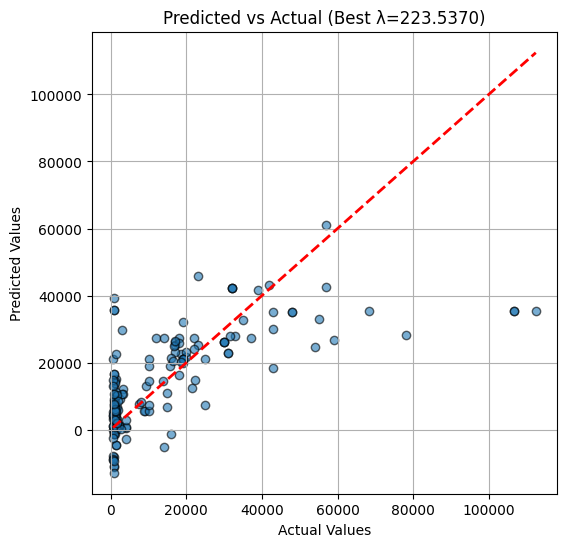

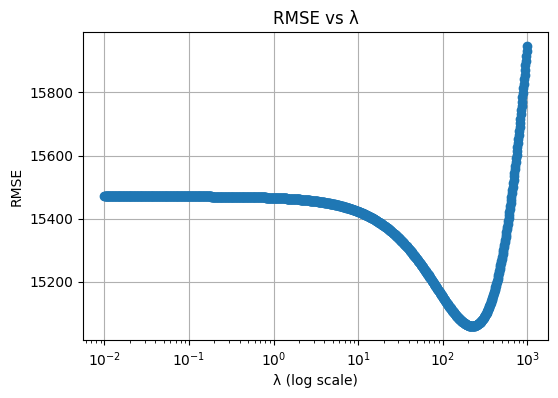

In [72]:
lambdaRange = np.logspace(-2, 3, 1000)  # from 0.01 to 1000
results = []

for lamVal in lambdaRange:
    wVal = ridgeClosed(xTrainClosed, yTrain, lam=lamVal)
    yPredVal = xTestClosed @ wVal
    rmseVal = root_mean_squared_error(yTest, yPredVal)
    r2Val = r2_score(yTest, yPredVal)
    results.append((lamVal, rmseVal, r2Val))

# every 20th iteration 
print("λ values at intervals:")
for i in range(0, len(results), 20):
    lamVal, rmseVal, r2Val = results[i]
    print(f"λ={lamVal:8.4f} | RMSE={rmseVal:.4f} | R^2={r2Val:.4f}")

# Best value of λ
bestLam, bestRmse, bestR2 = min(results, key=lambda t: t[1])

# Predictions for best λ
bestW = ridgeClosed(xTrainClosed, yTrain, lam=bestLam)
yPredBest = xTestClosed @ bestW

# Plot Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(yTest, yPredBest, alpha=0.6, edgecolor='k')
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], 'r--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Predicted vs Actual (Best λ={bestLam:.4f})")
plt.grid(True)
plt.show()

# RMSE vs λ curve
plt.figure(figsize=(6,4))
plt.semilogx([r[0] for r in results], [r[1] for r in results], marker='o')
plt.xlabel("λ (log scale)")
plt.ylabel("RMSE")
plt.title("RMSE vs λ")
plt.grid(True)
plt.show()


### Feature importance based on weight values after fitting the Regression with l2 regularization

In [63]:
wFeat = wRidgeClosedStd.flatten()   # includes bias term
featNames = np.array(["<bias>"] + list(X.columns))

absW = np.abs(wFeat[1:]) #skip bias
sortedIdx = np.argsort(-absW)  

print("Top features by absolute ridge weight (standardized):")
for i in range(len(sortedIdx)):
    j = sortedIdx[i] + 1  # +1 because bias is at index 0
    print(f"{i+1:>2}. {featNames[j]} | weight={wFeat[j]:.6f} | |w|={absW[sortedIdx[i]]:.6f}")


Top features by absolute ridge weight (standardized):
 1. Ratings | weight=7426.175058 | |w|=7426.175058
 2. RAM | weight=4306.688908 | |w|=4306.688908
 3. ROM | weight=4047.550188 | |w|=4047.550188
 4. Primary_Cam | weight=-3919.473839 | |w|=3919.473839
 5. Battery_Power | weight=2542.388301 | |w|=2542.388301
 6. Selfi_Cam | weight=607.240632 | |w|=607.240632
 7. Mobile_Size | weight=485.805587 | |w|=485.805587


## General Facts
<ul>
<li>Features with large positive weights increase the predicted price when they increase.
<li>Features with large negative weights decrease the predicted price.
<li>Features with near-zero weights have little predictive power (Ridge shrinks them).
<li>If some features dominate the list, they’re the most important drivers of mobile price.
</ul>

## Observation
<ul>
<li>Top 3 features (Ratings, RAM, ROM) dominate the price prediction, highlighting that customer satisfaction, performance, and storage capacity are the main drivers.
<li>Primary camera having a negative weight indicates that high megapixels are not always a sign of premium pricing.
<li>Battery and Selfie camera add value but are secondary.
<li>Mobile size has the least effect among the listed features.
</ul>
